# 📂 Data Loading and Setup
This cell imports necessary libraries and loads the dataset files.  
- `pandas` and `numpy` are used for data processing.  
- `random` is used for selection and mutation operations in the Genetic Algorithm.  
- `tabulate` formats the output schedule as a readable table.  
- `matplotlib.pyplot` (if used later) can help visualize results.

### **Datasets Loaded:**
- `teachers.csv`: Contains teacher names.
- `studentNames.csv`: Contains student names.
- `studentCourse.csv`: Maps students to their enrolled courses.
- `courses.csv`: List of all courses.

### **Defined Constants:**
- **DAYS:** Monday – Friday.
- **TIMESLOTS:** Available exam slots (`9-11`, `11-1`, `2-4`, `4-6`).
- **CLASSROOMS:** Available rooms (`C301` – `C310`).


In [21]:
# Cell 1: Imports and Data Loading
import pandas as pd
import numpy as np
import random
from tabulate import tabulate
import matplotlib.pyplot as plt

# Load datasets
teachers = pd.read_csv('Dataset/teachers.csv')
students = pd.read_csv('Dataset/studentNames.csv')
student_courses = pd.read_csv('Dataset/studentCourse.csv')
courses = pd.read_csv('Dataset/courses.csv')

# Define constants
DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
TIMESLOTS = ['9-11', '11-1', '2-4', '4-6']
CLASSROOMS = [f'C{i}' for i in range(301, 311)]

# 📊 Schedule Display Function
This function **formats and prints the exam schedule** in a structured table format.

### **Function: `display_schedule(schedule)`**
- **Input:** A dictionary where each course has assigned `(day, time slot, classroom, teacher)`.
- **Output:** A **grid-formatted table** showing:
  - Course Code  
  - Scheduled Day  
  - Exam Time Slot  
  - Assigned Classroom  
  - Invigilating Teacher  

### **Error Handling:**
- If the schedule is empty or improperly structured, warnings/errors are displayed.


In [22]:
# Cell 2: Utility Functions
def display_schedule(schedule):
    """Display the exam schedule in a formatted table."""
    if not schedule:
        print("Error: Empty schedule")
        return
        
    table = []
    for course, details in schedule.items():
        try:
            table.append([course, details[0], details[1], details[2], details[3]])
        except (IndexError, TypeError):
            print(f"Warning: Invalid schedule format for course {course}")
            continue
    
    if not table:
        print("Error: No valid schedule entries")
        return
        
    headers = ["Course Code", "Day", "Time Slot", "Classroom", "Invigilating Teacher"]
    print(tabulate(table, headers, tablefmt="grid"))

# 🧬 Chromosome Class (Individual Exam Schedule)
This class represents a **chromosome** in the Genetic Algorithm.  
Each chromosome is a possible **exam schedule** with constraints checked and a fitness score assigned.

### **Class: `Chromosome`**
- **Attributes:**
  - `schedule`: Dictionary storing the exam assignments.
  - `fitness`: Score based on constraint fulfillment.
  - `constraints_fulfilled`: List of satisfied constraints.

- **Method: `calculate_fitness()`**
  - **Hard Constraints Checked (Penalties Applied if Violated):**
    1. No overlapping student exams.
    2. No overlapping teacher exams.
    3. Exams must be on weekdays.
    4. Exams must be scheduled between `9 AM – 5 PM`.
    5. Teachers cannot invigilate consecutive exams.

  - **Soft Constraints Checked (Bonus Score if Met):**
    1. Common Friday `1–2 PM` break for all students and teachers.
    2. Avoiding back-to-back exams for students.
    3. MG courses scheduled **before** CS courses.
    4. A `2-hour faculty break` where at least half of the teachers are free.

### **Fitness Calculation**
- `fitness = rewards - penalties`
- The higher the fitness, the better the schedule.


In [23]:
# Cell 3: Chromosome Class
class Chromosome:
    def __init__(self, schedule):
        """Initialize a Chromosome with a given schedule.
        Calculate the fitness and constraints fulfilled for the schedule."""
        self.schedule = schedule
        self.fitness, self.constraints_fulfilled = self.calculate_fitness()

    def calculate_fitness(self):
        """
        Calculate the fitness of the schedule.
        Check various constraints and calculate penalties and rewards.
        
        Returns:
        tuple: Fitness value and list of constraints fulfilled.
        """
        fitness = 0
        penalties = 0
        rewards = 0
        constraints_fulfilled = []

        # Check for overlapping exams for students
        for student in students['Names']:
            student_courses_list = student_courses[student_courses['Student Name'] == student]['Course Code'].tolist()
            # Filter out courses that might not be in the schedule
            valid_courses = [course for course in student_courses_list if course in self.schedule]
            if valid_courses:  # Only check if student has valid courses
                exam_times = [(self.schedule[course][0], self.schedule[course][1]) for course in valid_courses]
                if len(exam_times) != len(set(exam_times)):
                    penalties += 1
                else:
                    constraints_fulfilled.append(f"No overlapping exams for student {student}")

        # Check for overlapping exams for teachers
        for teacher in teachers['Names']:
            teacher_exams = [course for course, details in self.schedule.items() if details[3] == teacher]
            exam_times = [(self.schedule[course][0], self.schedule[course][1]) for course in teacher_exams]
            if len(exam_times) != len(set(exam_times)):
                penalties += 1
            else:
                constraints_fulfilled.append(f"No overlapping exams for teacher {teacher}")

        # Check for exams scheduled only on weekdays
        for course, details in self.schedule.items():
            if details[0] not in DAYS:
                penalties += 1
            else:
                constraints_fulfilled.append(f"Exam for course {course} scheduled on a weekday")

        # Check for exam timings between 9 AM and 5 PM
        for course, details in self.schedule.items():
            if details[1] not in TIMESLOTS:
                penalties += 1
            else:
                constraints_fulfilled.append(f"Exam for course {course} scheduled between 9 AM and 5 PM")

        # Check for consecutive exam invigilation duties for teachers
        for teacher in teachers['Names']:
            teacher_exams = [course for course, details in self.schedule.items() if details[3] == teacher]
            teacher_exams.sort(key=lambda x: (self.schedule[x][0], self.schedule[x][1]))
            for i in range(len(teacher_exams) - 1):
                if self.schedule[teacher_exams[i]][0] == self.schedule[teacher_exams[i + 1]][0]:
                    penalties += 1
                else:
                    constraints_fulfilled.append(f"No consecutive invigilation duties for teacher {teacher}")

        # Common break on Friday from 1-2 PM
        friday_exams = [details for course, details in self.schedule.items() if details[0] == 'Friday']
        if all(details[1] != '1-2' for details in friday_exams):
            rewards += 1
            constraints_fulfilled.append("Common break on Friday from 1-2 PM")

        # No back-to-back exams for students
        for student in students['Names']:
            student_courses_list = student_courses[student_courses['Student Name'] == student]['Course Code'].tolist()
            exam_times = [(self.schedule[course][0], self.schedule[course][1]) for course in student_courses_list]
            exam_times.sort()
            for i in range(len(exam_times) - 1):
                if exam_times[i][0] == exam_times[i + 1][0] and abs(TIMESLOTS.index(exam_times[i][1]) - TIMESLOTS.index(exam_times[i + 1][1])) == 1:
                    penalties += 1
                else:
                    constraints_fulfilled.append(f"No back-to-back exams for student {student}")

        # MG course before CS course
        for student in students['Names']:
            student_courses_list = student_courses[student_courses['Student Name'] == student]['Course Code'].tolist()
            mg_courses = [course for course in student_courses_list if course.startswith('MG')]
            cs_courses = [course for course in student_courses_list if course.startswith('CS')]
            for mg_course in mg_courses:
                for cs_course in cs_courses:
                    if (self.schedule[mg_course][0], self.schedule[mg_course][1]) > (self.schedule[cs_course][0], self.schedule[cs_course][1]):
                        penalties += 1
                    else:
                        constraints_fulfilled.append(f"MG course {mg_course} scheduled before CS course {cs_course}")

        # Two-hour break for faculty meetings
        faculty_free_slots = {slot: 0 for slot in TIMESLOTS}
        for course, details in self.schedule.items():
            faculty_free_slots[details[1]] += 1
        if any(count <= len(teachers) / 2 for count in faculty_free_slots.values()):
            rewards += 1
            constraints_fulfilled.append("Two-hour break for faculty meetings")

        fitness = rewards - penalties
        return fitness, constraints_fulfilled

# 🌱 Initial Population Generation
This function creates an **initial set of random schedules** (chromosomes).  
Each schedule is generated by **randomly assigning** courses to time slots, classrooms, and teachers.

### Function: `generate_initial_population(size)`
- **Input:** `size` → Number of schedules (chromosomes) in the initial population.
- **Output:** A list of randomly generated Chromosome objects.

### **Random Assignment Process**
- Each course is **randomly assigned**:
  - A **day** from Monday–Friday.
  - A **time slot** from available slots.
  - A **classroom** from `C301–C310`.
  - An **invigilating teacher**.

This ensures genetic diversity in the first generation.


In [24]:
# Cell 4: Initial Population Generation
def initialize_population(size):
    """
    Generate initial population of random schedules.
    
    Args:
        size (int): Number of chromosomes in population
        
    Returns:
        list: List of Chromosome objects representing initial population
    """
    population = []
    for _ in range(size):
        schedule = generate_random_schedule()
        population.append(Chromosome(schedule))
    return population

def generate_random_schedule():
    """
    Create a random valid schedule for all courses.
    
    Returns:
        dict: Schedule mapping course codes to (day, timeslot, classroom, teacher)
    """
    schedule = {}
    course_codes = courses['Course Code'].tolist()
    
    for course_code in course_codes:
        # Randomly assign schedule components
        day = random.choice(DAYS)
        timeslot = random.choice(TIMESLOTS)
        classroom = random.choice(CLASSROOMS)
        teacher = random.choice(teachers['Names'].tolist())
        
        schedule[course_code] = (day, timeslot, classroom, teacher)
    
    return schedule

# 🧬 Genetic Algorithm Components (Selection, Crossover, and Mutation)
This cell contains key **Genetic Algorithm (GA) functions** used in the exam scheduling system.

---

## Roulette Wheel Selection
### Function: `roulette_wheel_selection(population)`
- **Purpose:** Selects a chromosome (schedule) based on its fitness score.
- **Process:**
  1. Calculate total fitness of the population.
  2. Assign selection probability proportional to fitness.
  3. Spin the roulette wheel (random selection based on probability).
  4. Return the selected chromosome.
- **Handling Edge Cases:** If all chromosomes have **zero fitness**, a **random chromosome** is selected to avoid stagnation.

---

## Two-Point Crossover
### Function: `crossover(parent1, parent2)`
- **Purpose:** Creates a new schedule by combining two parent schedules.
- **Process:**
  1. Select two crossover points randomly.
  2. Swap genes between parents within the crossover region.
  3. Resolve conflicts (teacher assignment conflicts).
  4. Return the new child chromosome.

### Conflict Resolution
- If a teacher is **assigned to multiple exams at the same time**, it attempts to **find an alternate teacher** using:
  - `has_teacher_conflict(schedule, course)`: Checks for conflicts.
  - `get_alternate_teacher(schedule, course)`: Finds an available teacher.

---

## Mutation for Genetic Diversity
### Function: `mutate(chromosome, mutation_rate)`
- **Purpose:** Introduces small random changes to the schedule to avoid premature convergence.
- **Mutation Probability:** Each gene (exam assignment) has a small chance of mutation.
- **Mutation Options:** One of the following **randomly changes**:
  - Exam Day → Assigns a new day.
  - Time Slot → Assigns a different available time slot.
  - Classroom → Assigns a different classroom.
  - Invigilating Teacher → Assigns a different available teacher.

### Intelligent Mutation Handling
- **Ensures constraints are not violated.**
- Uses `get_available_teachers(schedule, course)` to prevent teacher conflicts.
- **Recalculates fitness** after mutation.

---

## Helper Functions
- `has_teacher_conflict(schedule, course)` Checks if a teacher is assigned to multiple exams at the same time.

- `get_alternate_teacher(schedule, course)` Finds a substitute teacher if a conflict exists.

- `get_available_teachers(schedule, course)` Returns a list of teachers who are not busy in the same time slot.

---

## Summary
- **Roulette Wheel Selection:** Ensures fitter schedules have higher chances of being selected.
- **Two-Point Crossover:** Efficiently combines schedules while resolving conflicts.
- **Mutation:** Introduces random variations to prevent local optima.
- **Conflict Handling:** Avoids teacher double-booking issues.

This ensures that each new generation improves towards an **optimal exam schedule**.


In [25]:
# Cell 5: Genetic Algorithm Components
def roulette_wheel_selection(population):
    """Select a chromosome using roulette wheel selection."""
    max_fitness = sum([chromosome.fitness for chromosome in population])
    if max_fitness == 0:
        return random.choice(population)
    pick = random.uniform(0, max_fitness)
    current = 0
    for chromosome in population:
        current += chromosome.fitness
        if current > pick:
            return chromosome
    return random.choice(population)

def crossover(parent1, parent2):
    """Perform intelligent crossover between two parent schedules using two-point crossover."""
    child_schedule = {}
    course_list = list(parent1.schedule.keys())
    
    # Select two random crossover points
    point1, point2 = sorted(random.sample(range(len(course_list)), 2))
    
    # Perform two-point crossover
    for i, course in enumerate(course_list):
        if i < point1 or i > point2:
            child_schedule[course] = parent1.schedule[course]
        else:
            child_schedule[course] = parent2.schedule[course]
            
        # Conflict resolution for teacher assignments
        if has_teacher_conflict(child_schedule, course):
            alternate_teacher = get_alternate_teacher(child_schedule, course)
            if alternate_teacher:
                day, timeslot, classroom, _ = child_schedule[course]
                child_schedule[course] = (day, timeslot, classroom, alternate_teacher)
    
    return Chromosome(child_schedule)

def has_teacher_conflict(schedule, current_course):
    """Check if there's a teacher conflict in the schedule."""
    current_day, current_time, _, current_teacher = schedule[current_course]
    
    for course, (day, time, _, teacher) in schedule.items():
        if course != current_course:
            if (day == current_day and 
                time == current_time and 
                teacher == current_teacher):
                return True
    return False

def get_alternate_teacher(schedule, course):
    """Find an available teacher for the given timeslot."""
    day, timeslot, _, _ = schedule[course]
    busy_teachers = set()
    
    # Find busy teachers in this timeslot
    for c, (d, t, _, teacher) in schedule.items():
        if d == day and t == timeslot:
            busy_teachers.add(teacher)
            
    # Get available teachers
    available_teachers = set(teachers['Names'].tolist()) - busy_teachers
    
    return random.choice(list(available_teachers)) if available_teachers else None

def mutate(chromosome, mutation_rate):
    """Perform intelligent mutation on a chromosome's schedule."""
    for course in chromosome.schedule.keys():
        if random.random() < mutation_rate:
            # Decide which attribute to mutate (not all at once)
            attribute = random.choice(['day', 'time', 'room', 'teacher'])
            
            current_day, current_time, current_room, current_teacher = chromosome.schedule[course]
            
            if attribute == 'day':
                new_day = random.choice([d for d in DAYS if d != current_day])
                chromosome.schedule[course] = (new_day, current_time, current_room, current_teacher)
                
            elif attribute == 'time':
                new_time = random.choice([t for t in TIMESLOTS if t != current_time])
                chromosome.schedule[course] = (current_day, new_time, current_room, current_teacher)
                
            elif attribute == 'room':
                new_room = random.choice([r for r in CLASSROOMS if r != current_room])
                chromosome.schedule[course] = (current_day, current_time, new_room, current_teacher)
                
            elif attribute == 'teacher':
                available_teachers = get_available_teachers(chromosome.schedule, course)
                if available_teachers:
                    new_teacher = random.choice(list(available_teachers))
                    chromosome.schedule[course] = (current_day, current_time, current_room, new_teacher)
    
    # Recalculate fitness after mutation
    chromosome.fitness, chromosome.constraints_fulfilled = chromosome.calculate_fitness()

def get_available_teachers(schedule, course):
    """Helper function to find available teachers for a timeslot."""
    day, timeslot, _, _ = schedule[course]
    busy_teachers = set()
    
    for c, (d, t, _, teacher) in schedule.items():
        if c != course and d == day and t == timeslot:
            busy_teachers.add(teacher)
            
    return set(teachers['Names'].tolist()) - busy_teachers

# Main Genetic Algorithm Execution
This cell implements the **core genetic algorithm** that evolves an optimal exam schedule over multiple generations.

---

## Function: `genetic_algorithm(population_size, generations, mutation_rate)`
### Purpose:
- Runs the **full genetic algorithm** by iterating through selection, crossover, and mutation steps.
- Tracks **fitness improvements** over generations.
- Displays the **top 3 solutions** at each generation.

### **Process Flow:**
1. **Initialize Population**:
   - Generates `population_size` random schedules.
   - Tracks the **best fitness** of the initial generation.

2. **Iterate for `generations` steps**:
   - **Selection**: Uses **roulette wheel selection** to pick parent schedules.
   - **Crossover**: Applies **two-point crossover** to produce new schedules.
   - **Mutation**: Introduces small changes to maintain genetic diversity.
   - **Survivor Selection**: Keeps only the **best `population_size` schedules** for the next generation.

3. **Track and Display Progress:**
   - Logs **best fitness value** at each generation.
   - Displays **top 3 solutions** with fulfilled constraints.

4. **Plot Fitness Evolution**:
   - Plots the **best fitness value per generation** to visualize improvements over time.

---

## Key Tracking Variables
- `generation_stats`: Stores fitness and constraints fulfilled for each generation.
- `best_fitness_over_time`: Keeps a record of the **highest fitness score** in each generation.

---

## Displayed Outputs
- **Best Fitness per Generation**
- **Top 3 Solutions with Constraints**
- **Plot of Fitness Evolution Over Generations**

---

## Summary
- The algorithm **optimizes exam scheduling** while fulfilling constraints.
- It **evolves solutions over time** using selection, crossover, and mutation.
- **Visualization** helps understand **convergence trends**.

The function **returns the best schedule found** along with detailed stats.


In [26]:
# Cell 6: Main Genetic Algorithm
def genetic_algorithm(population_size, generations, mutation_rate):
    """Execute the genetic algorithm with detailed progress tracking."""
    population = initialize_population(population_size)
    generation_stats = []
    best_fitness_over_time = []

    # Track initial population stats
    initial_stats = {
        'generation': 0,
        'best_fitness': max(chr.fitness for chr in population),
        'top_3': sorted([(chr.fitness, chr.constraints_fulfilled) 
                        for chr in population], 
                        key=lambda x: x[0], 
                        reverse=True)[:3]
    }
    generation_stats.append(initial_stats)
    
    for generation in range(1, generations + 1):
        # Create new population
        new_population = []
        for _ in range(population_size // 2):
            parent1 = roulette_wheel_selection(population)
            parent2 = roulette_wheel_selection(population)
            child1 = crossover(parent1, parent2)
            child2 = crossover(parent1, parent2)
            mutate(child1, mutation_rate)
            mutate(child2, mutation_rate)
            new_population.extend([child1, child2])
        
        # Sort and select best individuals
        population = sorted(new_population, 
                          key=lambda x: x.fitness, 
                          reverse=True)[:population_size]
        
        # Track generation statistics
        gen_stats = {
            'generation': generation,
            'best_fitness': population[0].fitness,
            'top_3': [(chr.fitness, chr.constraints_fulfilled) 
                     for chr in population[:3]]
        }
        generation_stats.append(gen_stats)
        best_fitness_over_time.append(population[0].fitness)

        # Display generation progress
        print(f"\nGeneration {generation}:")
        print("-" * 50)
        print(f"Best Fitness: {gen_stats['best_fitness']}")
        print("\nTop 3 Solutions:")
        for i, (fitness, constraints) in enumerate(gen_stats['top_3'], 1):
            print(f"\nSolution {i}:")
            print(f"Fitness: {fitness}")
            print("Constraints Fulfilled:")
            for constraint in constraints[:3]:  # Show first 3 constraints
                print(f"  - {constraint}")
            print(f"  ... ({len(constraints)} total constraints)")
    
    # Plot fitness evolution
    plt.figure(figsize=(12, 6))
    plt.plot(range(generations + 1), 
            [stats['best_fitness'] for stats in generation_stats], 
            'b-', label='Best Fitness')
    plt.xlabel('Generation')
    plt.ylabel('Fitness Value')
    plt.title('Evolution of Best Fitness Over Generations')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    return population[0], generation_stats

# Display Final Results of Genetic Algorithm
This cell presents a **summary of the best schedule** found and tracks the **algorithm's progress**.

## Function: `display_final_results(best_solution, generation_stats)`
### Purpose:
- Displays the **best exam schedule** generated.
- Summarizes **fitness and constraints fulfilled**.
- Shows **generational progress** at intervals.

### Outputs:
1. **Best Schedule** → Formatted timetable.
2. **Final Fitness Score** → Indicates schedule quality.
3. **Constraints Fulfilled**:
   - **Essential Requirements** (Must-have constraints).
   - **Optimization Criteria** (Soft constraints).
4. **Generational Summary** → Best fitness values every 10 generations.

---

## Main Execution
- Runs the **genetic algorithm** with:
  - `population_size = 50`
  - `generations = 50`
  - `mutation_rate = 5%`
- Calls `display_final_results()` to present the final findings.



Generation 1:
--------------------------------------------------
Best Fitness: -17

Top 3 Solutions:

Solution 1:
Fitness: -17
Constraints Fulfilled:
  - No overlapping exams for student Mohammed Azam
  - No overlapping exams for student Ibrar Manawer
  - No overlapping exams for student Adam Flowers
  ... (408 total constraints)

Solution 2:
Fitness: -22
Constraints Fulfilled:
  - No overlapping exams for student Mohammed Azam
  - No overlapping exams for student Ibrar Manawer
  - No overlapping exams for student Adam Flowers
  ... (401 total constraints)

Solution 3:
Fitness: -22
Constraints Fulfilled:
  - No overlapping exams for student Mohammed Azam
  - No overlapping exams for student Ibrar Manawer
  - No overlapping exams for student Adam Flowers
  ... (402 total constraints)

Generation 2:
--------------------------------------------------
Best Fitness: -14

Top 3 Solutions:

Solution 1:
Fitness: -14
Constraints Fulfilled:
  - No overlapping exams for student Mohammed Azam
  -

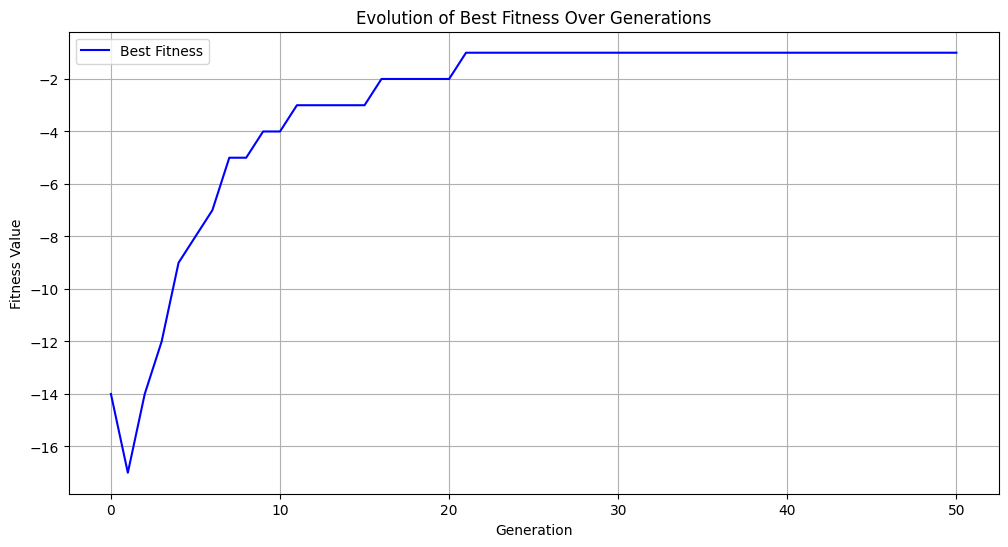


FINAL RESULTS

Best Schedule Found:
+---------------+-----------+-------------+-------------+------------------------+
| Course Code   | Day       | Time Slot   | Classroom   | Invigilating Teacher   |
+===============+===========+=============+=============+========================+
| CS217         | Tuesday   | 4-6         | C308        | Ameen Chilwan          |
+---------------+-----------+-------------+-------------+------------------------+
| EE227         | Monday    | 4-6         | C306        | Farwa Batool           |
+---------------+-----------+-------------+-------------+------------------------+
| CS211         | Monday    | 9-11        | C306        | Mehwish Hassan         |
+---------------+-----------+-------------+-------------+------------------------+
| SE110         | Friday    | 4-6         | C304        | Asif Naeem             |
+---------------+-----------+-------------+-------------+------------------------+
| CS118         | Monday    | 9-11        | C301  

In [27]:
# Display final results
def display_final_results(best_solution, generation_stats):
    """
    Display comprehensive results of the genetic algorithm run.
    
    Args:
        best_solution (Chromosome): Best solution found
        generation_stats (list): Statistics from each generation
    """
    print("\n" + "="*50)
    print("FINAL RESULTS")
    print("="*50)
    
    print("\nBest Schedule Found:")
    display_schedule(best_solution.schedule)
    
    print(f"\nFinal Fitness Value: {best_solution.fitness}")
    
    print("\nConstraints Fulfilled:")
    print("\nEssential Requirements:")
    essential = [c for c in best_solution.constraints_fulfilled 
                if any(key in c.lower() 
                for key in ['overlap', 'weekday', 'timing', 'consecutive'])]
    for constraint in essential:
        print(f"✓ {constraint}")
    
    print("\nOptimization Criteria:")
    optimization = [c for c in best_solution.constraints_fulfilled 
                   if c not in essential]
    for constraint in optimization:
        print(f"+ {constraint}")
    
    print("\nGenerational Progress Summary:")
    print("-" * 50)
    for i, stats in enumerate(generation_stats[::10]):  # Show every 10th generation
        print(f"\nGeneration {stats['generation']}:")
        print(f"Best Fitness: {stats['best_fitness']}")
        print(f"Top 3 Fitness Values: {[f[0] for f in stats['top_3']]}")

# Update main execution
if __name__ == "__main__":
    population_size = 50
    generations = 50
    mutation_rate = 0.05
    
    best_solution, stats = genetic_algorithm(population_size, generations, mutation_rate)
    display_final_results(best_solution, stats)